In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import *

In [2]:
%matplotlib widget

In [3]:
## On redéfinit les ondelettes
import numpy as np
import pywt
class wavelet:

    # -----------------------------------
    # Class constructor	
    # -----------------------------------
    def __init__(self, wavename):

        self.wavename = wavename	
        self.set_filters()

    # -----------------------------------
    # Creates the filters associated to the wavelet	
    # -----------------------------------		
    def set_filters(self):

        w = pywt.Wavelet(self.wavename)
        self.dec_high = w.dec_hi
        self.dec_low = w.dec_lo
        self.rec_high = w.rec_hi
        self.rec_low = w.rec_lo	

**Question 1**\
Pour montrer que, pour tout $j \in \mathbb{Z}$, $(\phi_{j,k})_{k \in \mathbb{Z}}$ est une base orthonormée de $V_j$, il suffit de montrer que :
1) pour $j \in \mathbb{Z}$, $(\phi_{j,k})_{k \in \mathbb{Z}}$ est une famille orthonormée
2) $\forall (j,k) \in \mathbb{Z}^2, \phi_{j,k} \in V_j$
3) pour $j \in \mathbb{Z}$, $(\phi_{j,k})_{k \in \mathbb{Z}}$ engendre $V_j$\


Point **1** : Soient $(j,k,l) \in \mathbb{Z}^3$ :\
$$\langle \phi_{j,k},\phi_{j,l} \rangle = \frac{1}{2^j} \int_{\mathbb{R}} \phi(\frac{t-2^jk}{2^j}) \phi(\frac{t-2^jl}{2^j}) dt$$
On effectue le changement de variable $u = \frac{t}{2^j}$ de sorte que $dt = 2^j \cdot du$ et il vient :\
$$
\langle \phi_{j,k},\phi_{j,l} \rangle = \int_{\mathbb{R}} \phi(u_k) \phi(u-l) du
=\langle \phi_{0,k},\phi_{0,l} \rangle
$$
Comme, par hypothèse, $(\phi_{0,k})_{k \in \mathbb{Z}}$ est orthonormée, il vient : \
$$\langle \phi_{j,k},\phi_{j,l} \rangle = \delta_{k,l}$$
Ce qui montre que $(\phi_{j,k})_{k \in \mathbb{Z}}$ est une famille orthonormée.\
\
Pour les points **2** et **3**, on procède par deux récurrences : une ascendante pour traiter les cas $j \geq 0$, et une descendante pour les cas $j \leq 0$. Comme la propriété d'*invariance par dilatation* est définie par une équivalence, ces deux récurrences sont très semblables. On ne traite donc ici que les cas $j \geq 0$ : \
On va montrer par récurrence sur $j \in \mathbb{N}$ les propriétés $P(j) = "\forall k \in \mathbb{Z}, \phi_{j,k} \in V_j"$ et $Q(j) = "(\phi_{j,k})_{k \in \mathbb{Z}}$ engendre $V_j"$\
Par hypothèse, on a $P(0)$ et $Q(0)$.
Soit $j \in \mathbb{Z}$. On suppose $P(j)$ et $Q(j)$: \
 - Soit $k \in \mathbb{Z}$. Par hypothèse de récurrence, $\phi_{j,k} \in V_j$. Par *invariance par translation*, $$(t \mapsto \phi_{j,k}(t-2^jk))\in V_{j+1}$$
 Or, pour $t\in \mathbb{R}$, $$\phi_{j,k}(t-2^jk) = \phi(\frac{t-2^jk-2^jk}{2^j})=\phi(\frac{t-2^{j+1}k}{2^j}) = \phi(2\frac{t-2^{j+1}k}{2^{j+1}})$$
 Par *invariance par dilatation*, $$t \mapsto \phi(\frac{t-2^{j+1}k}{2^{j+1}}) \in V_{j+1}$$
 ie $\phi_{j+1,k}\in V_{j+1,k}$, ce qui montre $Q(j+1)$.
  - Soit maintenant $f \in V_{j+1}$. Par *invariance par dilatation*, l'application $g:t \mapsto f(2t)$ est dans $V_j$. Par hypotjhèse de récurrence, il existe $(\lambda_k)_{k\in \mathbb{Z}}$ presque nulle telle que $$ g = \sum_{k\in \mathbb{Z}} \lambda_k \phi_{j,k}$$
  On a alors, pour tout $t \in \mathbb{R}$,
  $$ f(t) = \sum_{k\in \mathbb{Z}} \lambda_k \phi_{j,k}(\frac{t}{2})
   = \sum_{k\in \mathbb{Z}} \lambda_k \phi(\frac{t}{2^{j+1}}-k) 
   =\sum_{k\in \mathbb{Z}}\lambda_k \phi_{j+1,k}(t) $$
   Ce qui montre que $(\phi_{j+1,k})_{k\in \mathbb{Z}}$ engendre $V_{j+1}$.\
   \
   Par principe de récurrence, avec le point **1**, on a montré que, pour tout $j \in \mathbb{Z}$, $(\phi_{j,k})_{k \in \mathbb{Z}}$ est une base orthonormée de $V_j$.\
   \
   Exprimons à présent $\phi_{j+1,0}$ en fonction des $\phi_{j,k}$ : \
    - Par décroissance de la suite $(V_j)_{j \in \mathbb{Z}}$, on a $V_{j+1}\subset V_j$, donc, comme $(\phi_{j,k})_{k \in \mathbb{Z}}$ est une base (algébrique) orthonormée de $V_j$, $\phi_{j+1,0} = \sum_{k\in \mathbb{Z}} \langle \phi_{j+1,0},\phi_{j,k}\rangle \phi_{j,k}$ et cette somme n'a qu'un nombre fini de termes non-nuls.\
     - On fixe à présent $j \in \mathbb{Z}$ et, pour $k\in \mathbb{Z}$, on pose $h[k] = \langle \phi_{j+1,0},\phi_{j,k}\rangle$, qui dépend *a priori* de $j$. Soit $k\in \mathbb{Z}$ :
     $$h[k] = \int_{\mathbb{R}}\frac{1}{\sqrt{2^{2j+1}}}\phi(\frac{t}{2^{j+1}})\phi(\frac{t-2^jk}{2^j})dt$$
     On effectue alors le changement de variable $u= \frac{t}{2^j}$ de sorte que $du = \frac{dt}{2^j}$, et il vient
     $$h[k] = \int_{\mathbb{R}}\phi(\frac{u}{2})\phi(u-k)du$$
     qui est bien **indépendant de j**.
    Pour vérifier que $h$ est bien la réponse impulsionnelle (discrète) d'un filtre passe-bas (discret), on calcule sa *trasformée de Fourier en temps discret* et on vérifie qu'elle atténue les hautes fréquences : 
    
  

**Question 2**\
Soit $(j,k)\in \mathbb{Z}^2$. Par définition,
$$a_{j+1}[k] = \langle f,\phi_{j+1,0}(\cdot-2^{j+1}k)\rangle = \int_{\mathbb{R}}f(t)\phi_{j+1,0}(t-2^{j+1}k)dt\qquad(1)$$
On introduit la *relation d'échelle* : pour $t\in \mathbb{R}$
$$\phi_{j+1,0}(t-2^{j+1}k) = \sum_{p\in \mathbb{Z}}h[p]\phi_{j,p}(t-2^{j+1}k)$$
On réexprime à présent tout en fonction de la fonction $\phi$ : pour $p\in\mathbb{Z}$,
$$\phi_{j,p}(t-2^jk) = \frac{1}{\sqrt{2^j}}\phi(\frac{t-2^{j+1}k-2^jp}{2^j})$$
$$=\frac{1}{\sqrt{2^j}}\phi(\frac{t-2^j(2k+p)}{2^j})$$
$$=\phi_{j,2k+p}(t)$$
On remplace dans $(1)$ : 
$$a_{j+1}[k] =  \int_{\mathbb{R}}f(t)\sum_{p\in \mathbb{Z}}h[p]\phi_{j,2k+p}(t)dt$$
On a vu que la somme dans l'expression ci-dessus n'a qu'un nombre fini de termes non-nuls. On peut donc sans scrupule interchanger somme et intégrale par linéarité de l'intégrale, et on obtient : 
$$a_{j+1}[k] =  \sum_{p\in \mathbb{Z}}h[p]\int_{\mathbb{R}}f(t)\phi_{j,2k+p}(t)dt $$
$$= \sum_{p\in \mathbb{Z}}h[p]a_j[2k+p]$$
Par le changement d'indice $n = p + 2k$, on réécrit ce résultat :
$$a_{j+1,k} = \sum_{n\in\mathbb{Z}}h[n-2k]a_j[n]$$

**Question 3**

In [4]:
def convolution(x: np.ndarray, f: np.ndarray) -> np.ndarray:
    """
    Perform a 1D circular convolution between a signal and a filter.

    The signal is extended periodically in order to avoid boundary effects,
    and the result is cropped to preserve the original length of the signal.

    Parameters
    ----------
    x : np.ndarray
        One-dimensional input signal of length N.

    f : np.ndarray
        One-dimensional convolution filter of length L.

    Returns
    -------
    y : np.ndarray
        One-dimensional array of length N corresponding to the circular
        convolution of `x` with `f`.
    """
    N = x.size
    L = f.size
    if L<N:
        f = np.pad(f,(0,N-L))
    else :
        f = f[:N]
    return np.fft.ifft(np.fft.fft(x)*np.fft.fft(f))[:N].real

In [5]:
def conv(img: np.ndarray, wavename: str):
    """
    Apply a 1D wavelet analysis filter bank column-wise to a 2D image,
    followed by dyadic subsampling.

    This function performs the first step of a separable 2D wavelet transform.

    Parameters
    ----------
    img : np.ndarray
        2D input array of shape (NX, NY).

    wavename : str
        Name of the wavelet defining the analysis filters.

    Returns
    -------
    approx : np.ndarray
        Low-pass filtered and vertically subsampled image
        of shape (NX/2, NY).

    detail : np.ndarray
        High-pass filtered and vertically subsampled image
        of shape (NX/2, NY).
    """
    ondelette = wavelet(wavename)
    NX,NY = img.shape
    approx = np.empty((NX//2,NY),float)
    detail = np.empty((NX//2,NY),float) 
    L_h = len(ondelette.dec_high)
    L_l = len(ondelette.dec_low)
    for j in range(NY):
        signal = img[:,j]
        indices = (-np.arange(NX))%NX
        ondelette_rev = np.pad(ondelette.dec_low,(0,NX-L_l))[indices]
        approx_j = convolution(img[:,j],np.array(ondelette_rev))
        approx_j = approx_j[::2]
        approx[:,j] = approx_j
        indices = (-np.arange(NX))%NX
        ondelette_rev = np.pad(ondelette.dec_high,(0,NX-L_h))[indices]
        detail_j = convolution(img[:,j],np.array(ondelette_rev))
        detail_j = detail_j[::2]
        detail[:,j]=detail_j
    return approx,detail

In [6]:
def iconv_low(x: np.ndarray, wavename: str):
    ondelette = wavelet(wavename)
    nx, NY = x.shape
    NX = 2 * nx
    y = np.empty((NX, NY), float)
    L = len(ondelette.rec_low)
    for j in range(NY):
        signal = x[:, j]
        up = np.zeros(NX)
        for i in range(nx):
            up[2*i] = signal[i]
        # Renversement du filtre (comme dans conv)
        indices = (-np.arange(NX)) % NX
        g = np.pad(ondelette.rec_low, (0, NX-L))[indices]
        y_j = convolution(up, g)
        # Compensation du décalage circulaire de -(L-1)
        y[:, j] = np.roll(y_j, L-1)
    return y

def iconv_high(x: np.ndarray, wavename: str):
    ondelette = wavelet(wavename)
    nx, NY = x.shape
    NX = 2 * nx
    y = np.empty((NX, NY), float)
    L = len(ondelette.rec_high)
    for j in range(NY):
        signal = x[:, j]
        up = np.zeros(NX)
        for i in range(nx):
            up[2*i] = signal[i]
        # Renversement du filtre
        indices = (-np.arange(NX)) % NX
        g = np.pad(ondelette.rec_high, (0, NX-L))[indices]
        y_j = convolution(up, g)
        # Compensation du décalage circulaire de -(L-1)
        y[:, j] = np.roll(y_j, L-1)
    return y

In [7]:
def dwt2D(x: np.ndarray, wavename: str, dec_level=3):
    """
    Compute the 2D Discrete Wavelet Transform (DWT) of an image.

    The transform is implemented using separable 1D wavelet filter banks
    applied successively along columns and rows.

    Parameters
    ----------
    x : np.ndarray
        2D input image of shape (NX, NY).

    wavename : str
        Name of the wavelet used for decomposition.

    dec_level : int or float, optional
        Maximum number of decomposition levels.
        Default is 3.

    Returns
    -------
    coeff : list
        Multiscale wavelet coefficient structure:
        - coeff[0] to coeff[L-1]: detail coefficients [cH, cV, cD]
          at each scale (from finest to coarsest),
        - coeff[-1]: list containing the final coarse approximation [cA].
    """
    L = dec_level
    if L == 0 :
        coeff = [[x]] # a priori, pas besoin de faire une copie car rien ne se fait en place
    else :
        coeff = dwt2D(x,wavename,L-1)
        cA_precedent = coeff.pop()[0]#attention le dernier élément est une liste
        passe_bas_lignes,passe_haut_lignes = conv(cA_precedent.T,wavename)
        LL,LH = conv(passe_bas_lignes.T,wavename)
        HL,HH = conv(passe_haut_lignes.T,wavename)
        coeff += [[LH,HL,HH],[LL]]
    return coeff


In [8]:
from collections import deque
def idwt2D(coeff: list, wavename: str):
    """
    Reconstruct a 2D image from its wavelet coefficients.

    This function performs the inverse 2D discrete wavelet transform
    using separable synthesis filter banks.

    Parameters
    ----------
    coeff : list
        Wavelet coefficient structure as returned by `dwt2D`.

    wavename : str
        Name of the wavelet used for reconstruction.

    Returns
    -------
    x : np.ndarray
        Reconstructed 2D image.
    """
    L = len(coeff)-1
    if L == 0 :
        x = coeff[0][0]
    else :
        coeff = deque(coeff)
        [LH,HL,HH] = coeff.popleft() # details d'ordre 1
        LL = idwt2D(coeff,wavename) # approximation à l'ordre 1
        passe_bas_lignes = iconv_low(LL,wavename) + iconv_high(LH,wavename)
        passe_haut_lignes = iconv_low(HL,wavename)+iconv_high(HH,wavename)
        x = (iconv_low(passe_bas_lignes.T,wavename) + iconv_high(passe_haut_lignes.T,wavename)).T
    return x

**Question 4**

In [9]:
def display_transform(coeff: list) -> np.ndarray:
    """
    Create a 2D visualization of wavelet coefficients following
    the standard LL/LH/HL/HH layout.

    Parameters
    ----------
    coeff : list
        Wavelet coefficient list as returned by `dwt2D`.

    Returns
    -------
    img : np.ndarray
        Image-like array suitable for visualization.
    """
    def normalize(arr):
        if arr.size == 1:
            return arr[0, 0]
        a, b = arr.min(), arr.max()
        if b > a:
            return 255 * (arr - a) / (b - a)
        return np.zeros_like(arr)

    NX, NY = coeff[0][0].shape
    img = np.zeros((2 * NX, 2 * NY))

    LX, LY = coeff[-1][0].shape
    img[:LX, :LY] = normalize(coeff[-1][0])

    for scale in reversed(coeff[:-1]):
        cH, cV, cD = scale

        img[LX:2 * LX, :LY] = normalize(cH)
        img[:LX, LY:2 * LY] = normalize(cV)
        img[LX:2 * LX, LY:2 * LY] = normalize(cD)

        img[LX, :] = 255
        img[:, LY] = 255

        LX *= 2
        LY *= 2

    return img

In [10]:
from skimage.io import imread, imsave
from skimage import img_as_float

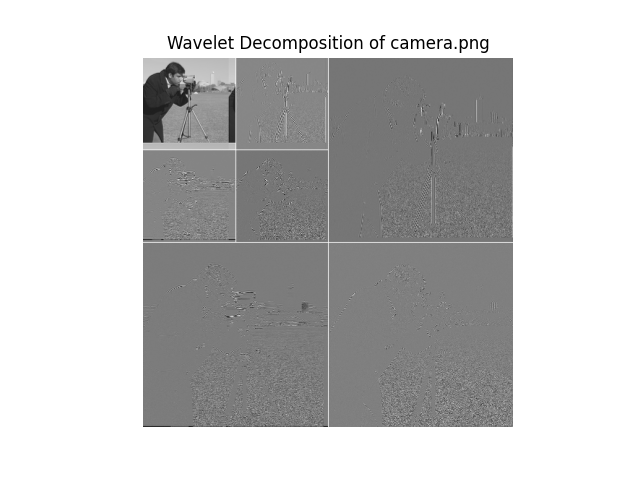

In [11]:
original = img_as_float(imread('src/camera.png'))
WAVENAME = 'db8'
coefs = dwt2D(original, WAVENAME, dec_level=2)
coefs_display = display_transform(coefs)
plt.figure()
plt.title("Wavelet Decomposition of camera.png")
plt.imshow(coefs_display, cmap='gray')
plt.axis('off')
plt.show()

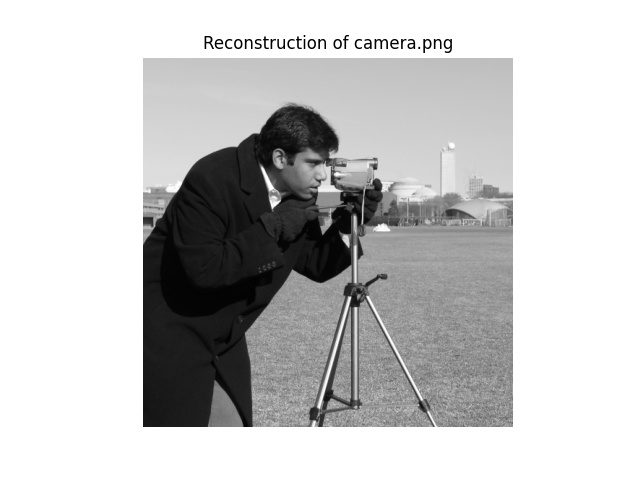

In [12]:
reconst = idwt2D(coefs,WAVENAME).real
plt.figure()
plt.title("Reconstruction of camera.png")
plt.imshow(reconst, cmap='gray')
plt.axis('off')
plt.show()

In [13]:
## Quelques outils pour la suite
def vectorRepresentation(coeff: list) -> np.ndarray:
    """
    Convert a multiscale wavelet coefficient representation into
    a single one-dimensional vector.

    Parameters
    ----------
    coeff : list
        Wavelet coefficient list as returned by `dwt2D`.

    Returns
    -------
    vec : np.ndarray
        Flattened vector containing all wavelet coefficients
        concatenated scale by scale.
    """
    return np.concatenate([band.ravel() for scale in coeff for band in scale])


def scaleRepresentation(vec: np.ndarray, shape: tuple, dec_level=np.inf)-> list:
    """
    Reconstruct a multiscale wavelet coefficient structure from
    a vectorized representation.

    Parameters
    ----------
    vec : np.ndarray
        One-dimensional array of wavelet coefficients.

    shape : tuple
        Shape (NX, NY) of the original image.

    dec_level : int or float, optional
        Maximum number of decomposition levels.

    Returns
    -------
    coeff : list
        Wavelet coefficient structure compatible with `idwt2D`.
    """
    NX, NY = shape
    idx = 0
    coeff = []
    level = 0

    while level < dec_level and NX > 1 and NY > 1:
        NX //= 2
        NY //= 2
        N = NX * NY

        cH = vec[idx:idx + N].reshape(NX, NY)
        cV = vec[idx + N:idx + 2 * N].reshape(NX, NY)
        cD = vec[idx + 2 * N:idx + 3 * N].reshape(NX, NY)

        coeff.append([cH, cV, cD])
        idx += 3 * N
        level += 1

    coeff.append([vec[idx:].reshape(NX, NY)])
    return coeff


In [14]:
vec = vectorRepresentation(coefs)
coefs_test = scaleRepresentation(vec, shape =(512, 512), dec_level=2)

In [15]:
def dwt2D_compression(x: np.ndarray, 
    wavename: str, 
    dec_level: int, eps :float
) -> np.ndarray:
    """
    Insert here your compression code using the wavelet decomposition of the
    image. Feel free to add any parameter to the function
    A simulation of the compression-decompression process using wavelets

    Parameters
    ----------
    x : np.ndarray
        Input image.

    wavename : str
        Wavelet used for the transform.
    eps : float
        threshold under which wavelet coefficients will be set to zero (hard thresholding)

    Returns
    -------
    res : np.ndarray
        Reconstructed compressed image.
    """
    coeff = dwt2D(x,wavename,dec_level)
    vec = vectorRepresentation(coeff)
    for i in range(len(vec)):
        if abs(vec[i]) < eps :
            vec[i] =0
    return idwt2D(scaleRepresentation(vec,x.shape,dec_level),wavename)

In [16]:
def epsilon(x:np.ndarray,taux:float,wavename : str,dec_level = 3,mini = 0.01)->float:
    """Returns the minimal parameter eps to pass dwt2D_compression in order to compress x with a compression rate of at least taux
    Parameters 
    ------
    x : np.ndarray
        oiginal image to compress, stored as floats with values between 0 and 1
    taux : float
        required compression rate defined by taux = 1-(compressed_size/original_size), expressed as a float between 0 and 1
    wavename, dec_level : refer to the docstring of dwt2D_compresion
    mini : float
        precision in the search for eps (0<mini<=1). The greater the value, the faster the algorithm, but the greater the over-compression risk
    Returns
    ------
    eps : float 
        to be passed directly into dwt2D_compression
    """
    coefs = dwt2D(x,wavename,dec_level)
    vec = vectorRepresentation(coefs)
    for eps in np.linspace(0,1,floor(1/mini)):
        coeffs_restants = [coef for coef in vec if abs(coef)<eps]
        tau = 1-len(coeffs_restants)/len(vec)
        if tau>taux:
            return eps
    return 1

Reconstruction MSE: 0.000000


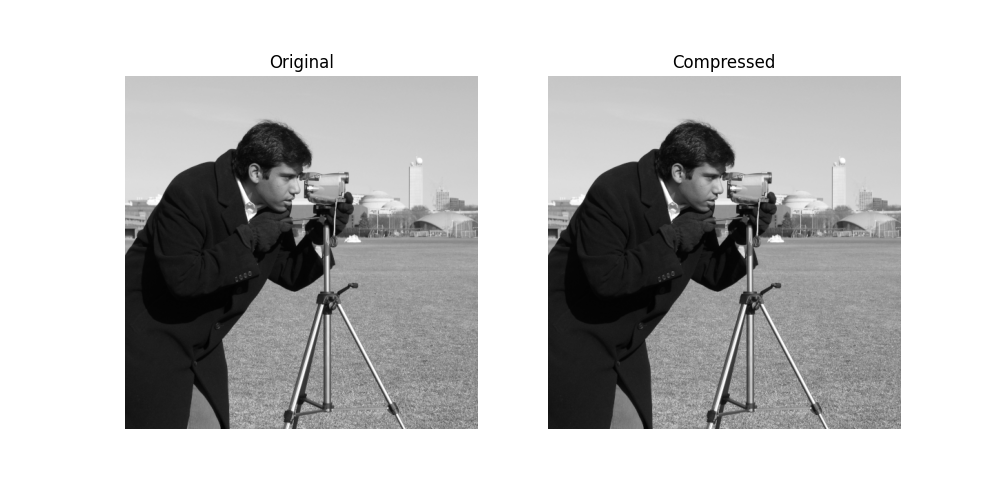

In [17]:
compression_rate = 0.1
threshold = epsilon(original,compression_rate,WAVENAME,dec_level = 2)
k = int(compression_rate * original.size)
compressed = dwt2D_compression(original, WAVENAME, dec_level=2,eps = threshold)
mse_compressed = np.mean((original - compressed) ** 2)
print(f"Reconstruction MSE: {mse_compressed:.6f}")
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Compressed")
plt.imshow(compressed, cmap='gray')
plt.axis('off')
plt.show()
    

**Question 5**

In [18]:
noisy = img_as_float(imread('src/noisy.png'))
mse_noisy = np.mean((noisy - original) ** 2)
print(f"Noisy MSE: {mse_noisy:.6f}")

Noisy MSE: 0.009025


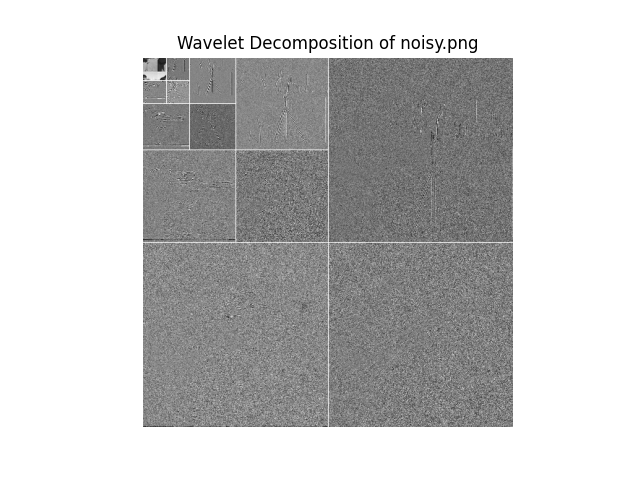

In [ ]:
WAVENAME = 'db8'
coefs = dwt2D(noisy, WAVENAME, dec_level=4)
coefs_display = display_transform(coefs)
plt.figure()
plt.title("Wavelet Decomposition of noisy.png")
plt.imshow(coefs_display, cmap='gray')
plt.axis('off')
plt.show()

In [19]:
denoised = dwt2D_denoising(noisy, 'db4', dec_level=4,eps = 0)
mse_denoised = np.mean((original - denoised) ** 2)
print(f"Denoised MSE: {mse_denoised:.6f}")

plt.figure(figsize=(15,5))
plt.subplot(1,3,1) 
plt.title("Noisy")
plt.imshow(noisy, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title("Original")
plt.imshow(original, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title("Denoised")
plt.imshow(denoised, cmap='gray')
plt.axis('off')
plt.show()

NameError: name 'dwt2D_denoising' is not defined